# TEMPO — Full EM on Trajectories

**TEMPO** fits a mixture of $M$ regime-specific bases via EM.
Each unit of clustering is a **full spatiotemporal trajectory** $\mathbf{s}^n \in \mathbb{R}^{N_t N_x}$.

EM alternates between:
- **E-step**: recompute soft regime assignments $\gamma_{nm}$ from reconstruction errors
- **M-step**: update mixture weights $\pi_m$ and retrain bases with new $\gamma$

In [1]:
import os, sys, pathlib
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
from umap import UMAP

sys.path.insert(0, str(pathlib.Path("..").resolve()))
from models.tempo import TEMPOTrainer, TEMPOConfig, pod_factory, fourier_pod_factory
from models.pod import PODConfig
from models.fourier_neural_pod import FourierNeuralPODConfig
from models.tempo_online import build_tempo_online, TEMPOOnlineConfig, _num_modes
from utils.datasets import load_stacked

if torch.backends.mps.is_available():   DEVICE = 'mps'
elif torch.cuda.is_available():         DEVICE = 'cuda'
else:                                   DEVICE = 'cpu'

# path to DaRUS-downloaded HDF5 files on the server
DATA_DIR = os.path.expanduser("/Users/rknza/research/m1p/project/code/data")


def draw_cov_ellipse(ax, mean2d, cov2d, color, n_std=2.0, **kwargs):
    vals, vecs = np.linalg.eigh(cov2d)
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    w, h  = 2 * n_std * np.sqrt(np.abs(vals))
    ellipse = Ellipse(mean2d, w, h, angle=angle,
                      edgecolor=color, facecolor="none", lw=2, **kwargs)
    ax.add_patch(ellipse)

In [2]:
nu_values = [0.001, 0.01, 0.1, 1.0]
N_samples  = 5000   # per nu; 4×5000×103424×4B ≈ 8 GB numpy + 8 GB torch


In [5]:
entries = [
    (nu, os.path.join(DATA_DIR, f"Burgers_Nu{nu}.hdf5"))
    for nu in nu_values
]
s_np, kappa_np, x_np, t_np, Nx, Nt = load_stacked(entries, n_samples=N_samples)
Ny = Nt * Nx

x_grid = torch.tensor(x_np, dtype=torch.float32)
t_grid = torch.tensor(t_np, dtype=torch.float32)
tt, xx = torch.meshgrid(t_grid, x_grid, indexing='ij')
x_flat = torch.stack([xx.flatten(), tt.flatten()], dim=1)   # (Ny, 2)

s     = torch.from_numpy(s_np);              del s_np
kappa = torch.from_numpy(kappa_np[:, None]); del kappa_np
x     = x_flat.to(DEVICE)

print(f"s={s.shape}, x={x.shape}, kappa={kappa.shape}")


Nt=256, Nx=101, n_per_kappa=5000, N_total=20000, s≈2.1 GB
  kappa=0.001: 5000 trajectories loaded
  kappa=0.01: 5000 trajectories loaded
  kappa=0.1: 5000 trajectories loaded
  kappa=1.0: 5000 trajectories loaded
s=torch.Size([20000, 25856]), x=torch.Size([25856, 2]), kappa=torch.Size([20000, 1])


In [6]:
# shapes printed above

In [7]:
cfg = TEMPOConfig(
    M=3,
    P_global=20,
    sigma2=0.1,
    max_em_iters=10,
    eps_skip=0.01,
    eps_large=0.1,
    eps_conv=0.005,
    basis_config=PODConfig(max_modes=32),
    basis_factory=pod_factory,
)

# --- Alternative: NeuralPOD basis ---
# cfg = TEMPOConfig(
#     M=3, P_global=20, sigma2=0.1, max_em_iters=10,
#     eps_skip=0.01, eps_large=0.1, eps_conv=0.005,
#     basis_config=FourierNeuralPODConfig(max_modes=5, n_epochs_mean=165, n_epochs_mode=85),
#     basis_factory=fourier_pod_factory,
# )

regime_colors = plt.cm.Set1(np.linspace(0, 0.8, cfg.M))

In [ ]:
trainer = TEMPOTrainer(cfg)
trainer.train(s, x, t=None, kappa=kappa)

POD | N=20000, Ny=25856 | max_modes=20, tol=1.0


### Results — EM regime structure

In [7]:
N_viz = min(5632, len(s))
idx   = np.random.choice(len(s), N_viz, replace=False)

kappa_viz   = kappa[idx, 0].cpu().numpy()
alpha_viz   = trainer.alpha[idx].cpu().numpy()
hard_labels = trainer.gamma[idx].argmax(dim=1).cpu().numpy()
mu_np       = trainer.mu.cpu().numpy()   # (M, P_global)

UMAP of trajectory coefficients $\alpha^n \in \mathbb{R}^P$:

In [8]:
reducer   = UMAP(n_neighbors=30, min_dist=0.0)
embedding = reducer.fit_transform(alpha_viz)
mu_umap   = reducer.transform(mu_np)

Visualization:

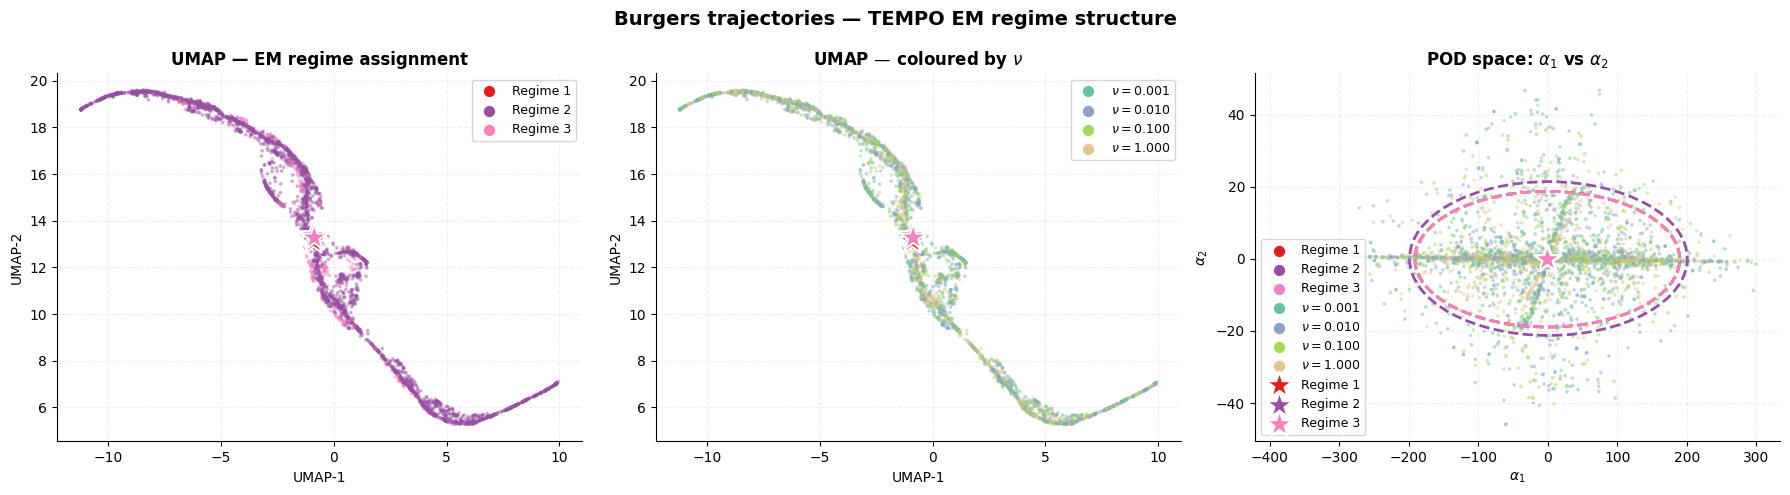

In [9]:
nu_unique    = np.unique(kappa_viz)
nu_palette   = plt.cm.Set2(np.linspace(0, 0.8, len(nu_unique)))
nu_to_col    = {nu: c for nu, c in zip(nu_unique, nu_palette)}
point_colors = np.array([nu_to_col[float(nu)] for nu in kappa_viz])

star_kw = dict(s=400, marker="*", zorder=10, edgecolors="white", linewidths=1.5)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 0: UMAP coloured by regime
axes[0].scatter(embedding[:, 0], embedding[:, 1],
                c=regime_colors[hard_labels], s=3, alpha=0.35, rasterized=True)
axes[0].scatter(mu_umap[:, 0], mu_umap[:, 1], c=regime_colors, **star_kw)
axes[0].set_title("UMAP — EM regime assignment", fontweight="bold")
handles = [plt.scatter([], [], color=regime_colors[m], s=50, label=f"Regime {m+1}")
           for m in range(cfg.M)]
axes[0].legend(handles=handles, fontsize=9)

# Panel 1: UMAP coloured by ν
axes[1].scatter(embedding[:, 0], embedding[:, 1],
                c=point_colors, s=3, alpha=0.35, rasterized=True)
axes[1].scatter(mu_umap[:, 0], mu_umap[:, 1], c=regime_colors, **star_kw)
axes[1].set_title(r"UMAP — coloured by $\nu$", fontweight="bold")
handles = [plt.scatter([], [], color=nu_to_col[nu], s=50,
                       label=rf"$\nu = {nu:.3f}$") for nu in nu_unique]
axes[1].legend(handles=handles, fontsize=9)

# Panel 2: POD coefficient space α_1 vs α_2
axes[2].scatter(alpha_viz[:, 0], alpha_viz[:, 1],
                c=point_colors, s=3, alpha=0.35, rasterized=True)
for m in range(cfg.M):
    cov2d  = trainer.Sigma[m, :2, :2].cpu().numpy()
    mean2d = mu_np[m, :2]
    draw_cov_ellipse(axes[2], mean2d, cov2d, color=regime_colors[m], linestyle="--")
    axes[2].scatter(*mean2d, color=regime_colors[m], **star_kw, label=f"Regime {m+1}")
axes[2].set_title(r"POD space: $\alpha_1$ vs $\alpha_2$", fontweight="bold")
axes[2].set_xlabel(r"$\alpha_1$"); axes[2].set_ylabel(r"$\alpha_2$")
axes[2].legend(fontsize=9)

for ax in axes[:2]:
    ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
for ax in axes:
    ax.grid(True, ls="--", alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Burgers trajectories — TEMPO EM regime structure",
             fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

## Phase 2 — Online Gated Operator

Bases $\{\Phi_m^*\}$ and responsibilities $\{\gamma_{im}^*\}$ are frozen.
We train a **GatingNet** $\mathcal{W}(u_0, \kappa) \to \Delta^{M-1}$ and $M$ **BranchNets** $\mathcal{B}_m(u_0, \kappa) \to \mathbb{R}^{P_m}$.

Loss: $\mathcal{L} = \mathcal{L}_{\mathrm{data}} + \lambda_{\mathrm{KL}}\,\mathcal{L}_{\mathrm{KL}} - \lambda_H\,\mathcal{L}_{\mathrm{ent}}$

In [ ]:
# Train/test split — last 1000 trajectories per nu reserved for test
N_test_per_nu = 1000
N_per_nu      = N_samples  # trajectories loaded per nu value

train_idx = torch.cat([torch.arange(i*N_per_nu, (i+1)*N_per_nu - N_test_per_nu)
                       for i in range(len(nu_values))])
test_idx  = torch.cat([torch.arange((i+1)*N_per_nu - N_test_per_nu, (i+1)*N_per_nu)
                       for i in range(len(nu_values))])

# Initial condition: first spatial slice of each trajectory (t = 0)
u0 = s[:, :Nx]  # (N_total, Nx)

s_train     = s[train_idx];     s_test     = s[test_idx]
u0_train    = u0[train_idx];    u0_test    = u0[test_idx]
kappa_train = kappa[train_idx]; kappa_test = kappa[test_idx]
gamma_train = trainer.gamma[train_idx]

print(f'train: {s_train.shape}, test: {s_test.shape}')

In [ ]:
cfg_online = TEMPOOnlineConfig(
    lr=3e-4,
    n_epochs=1000,
    batch_size=64,
    hidden_dim=128,
    n_layers=4,
    sensor_stride=4,   # Nx=1024 -> 256 sensors
    lambda_kl=0.1,
    lambda_ent=0.1,
    log_every=100,
)

model_online, online_trainer = build_tempo_online(
    trainers=trainer.trainers,
    d_kappa=kappa.shape[1],
    Nx=Nx,
    cfg=cfg_online,
)
model_online = model_online.to(DEVICE)

for m, t in enumerate(trainer.trainers):
    print(f'Regime {m+1}: P={_num_modes(t)} modes')

In [ ]:
history = online_trainer.train(
    s=s_train,
    u0=u0_train,
    kappa=kappa_train,
    x_flat=x,
    gamma_star=gamma_train,
    trainers=trainer.trainers,
)

### Training dynamics

In [ ]:
epochs = range(len(history['total']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history['total'], label='total', lw=2)
axes[0].plot(epochs, history['data'],  label=r'$\mathcal{L}_{\mathrm{data}}$', lw=1.5, ls='--')
axes[0].set_title('Total loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].set_yscale('log')

axes[1].plot(epochs, history['kl'],  label=r'$\mathcal{L}_{\mathrm{KL}}$',  lw=1.5)
axes[1].plot(epochs, history['ent'], label=r'$\mathcal{L}_{\mathrm{ent}}$', lw=1.5, ls='--')
axes[1].set_title('Regularisation terms', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].legend()

for ax in axes:
    ax.grid(True, ls='--', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

### Gating & reconstruction quality on test set

In [ ]:
s_pred, w_pred = online_trainer.predict(
    u0_new=u0_test, kappa_new=kappa_test,
    x_flat=x, trainers=trainer.trainers,
)

s_pred_np    = s_pred.cpu().numpy()
s_test_np    = s_test.numpy()
w_np         = w_pred.cpu().numpy()          # (N_test, M)
kappa_t_np   = kappa_test[:, 0].numpy()
nu_unique_t  = np.unique(kappa_t_np)
nu_to_col_t  = {nu: c for nu, c in zip(nu_unique_t,
               plt.cm.Set2(np.linspace(0, 0.8, len(nu_unique_t))))}

# Relative L2 per trajectory
rel_l2 = (np.linalg.norm(s_pred_np - s_test_np, axis=1)
          / np.linalg.norm(s_test_np, axis=1))
print('Mean rel L2 error:')
for nu in nu_unique_t:
    mask = kappa_t_np == nu
    print(f'  nu={nu:.3f}: {rel_l2[mask].mean():.4f} +/- {rel_l2[mask].std():.4f}')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Panel 0: mean gating weight per nu
x_pos = np.arange(len(nu_unique_t))
width = 0.8 / cfg.M
for m in range(cfg.M):
    w_m = [w_np[kappa_t_np == nu, m].mean() for nu in nu_unique_t]
    axes[0].bar(x_pos + m*width, w_m, width,
               color=regime_colors[m], label=f'Regime {m+1}', alpha=0.85)
axes[0].set_xticks(x_pos + width*(cfg.M-1)/2)
axes[0].set_xticklabels([rf'$\nu={nu:.3f}$' for nu in nu_unique_t])
axes[0].set_ylabel('Mean gating weight')
axes[0].set_title('Gating weights per viscosity', fontweight='bold')
axes[0].legend(fontsize=9)

# Panel 1: rel L2 boxplot per nu
bp_data = [rel_l2[kappa_t_np == nu] for nu in nu_unique_t]
bp = axes[1].boxplot(bp_data, patch_artist=True, widths=0.5)
for patch, nu in zip(bp['boxes'], nu_unique_t):
    patch.set_facecolor(nu_to_col_t[nu]); patch.set_alpha(0.75)
axes[1].set_xticklabels([rf'$\nu={nu:.3f}$' for nu in nu_unique_t])
axes[1].set_ylabel('Relative $L^2$ error')
axes[1].set_title('Reconstruction error by viscosity', fontweight='bold')

for ax in axes:
    ax.grid(True, ls='--', alpha=0.25, axis='y')
    ax.spines[['top','right']].set_visible(False)
plt.suptitle('TEMPO Phase 2 — test set results', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

### Reconstruction examples

In [ ]:
fig, axes = plt.subplots(len(nu_unique_t), 3,
                         figsize=(13, 3.5*len(nu_unique_t)))

for row, nu in enumerate(nu_unique_t):
    idx_nu  = np.where(kappa_t_np == nu)[0][0]
    s_true  = s_test_np[idx_nu].reshape(Nt, Nx)
    s_hat_r = s_pred_np[idx_nu].reshape(Nt, Nx)
    err     = np.abs(s_true - s_hat_r)
    vmin, vmax = s_true.min(), s_true.max()

    kw = dict(aspect='auto', origin='lower', extent=[x_np.min(), x_np.max(),
                                                      t_np.min(), t_np.max()])
    axes[row, 0].imshow(s_true,   vmin=vmin, vmax=vmax, cmap='RdBu_r', **kw)
    axes[row, 1].imshow(s_hat_r,  vmin=vmin, vmax=vmax, cmap='RdBu_r', **kw)
    im = axes[row, 2].imshow(err, cmap='Reds', **kw)
    plt.colorbar(im, ax=axes[row, 2], fraction=0.046)

    axes[row, 0].set_title(rf'$\nu={nu:.3f}$ — ground truth')
    axes[row, 1].set_title(rf'$\nu={nu:.3f}$ — TEMPO')
    axes[row, 2].set_title(rf'$\nu={nu:.3f}$ — |error|')
    for ax in axes[row]:
        ax.set_xlabel('x'); ax.set_ylabel('t')

plt.suptitle('Space-time reconstructions — TEMPO(POD)', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()